# Classification

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import h5py

from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

In [43]:
# use latex
plt.rc('text', usetex=True)
# set font size
plt.rc('font', size=14)

In [44]:
dataset = "RR"
t1 = 0.4
seed = 2

methods = ["One-hot", "RBM", "Foundation"]
method_to_id = {
    "One-hot": "onehot",
    "RBM": "rbm",
    "Foundation": "plm",
}
path_repo = f"../outputs/{dataset}/t1_{t1}/seed_{seed}/predictions"

In [45]:
def load_data(method, num_train_samples, seed):
    filename = f"test.embedding.{method_to_id[method]}.ntrain_{num_train_samples}.predictions.h5"
    path = os.path.join(path_repo, filename)
    data = h5py.File(path, "r")
    return data

In [49]:
data = load_data("One-hot", 5000, 1)
# print the internal structure of the data object
def print_structure(obj, indent=0):
    for key in obj.keys():
        print(" " * indent + str(key))
        if isinstance(obj[key], h5py.Group):
            print_structure(obj[key], indent + 4)
print_structure(data)

info
test
    headers
    labels_true
    predictions
        SVM
            labels_pred
            labels_probs
        logreg
            labels_pred
            labels_probs
        random_forest
            labels_pred
            labels_probs
train
    headers
    labels_true


In [47]:
def _label_score_column(y_true, y_probs, label):
    """Return binary targets and score vector for a given label, handling binary/multiclass outputs."""
    unique_labels = np.unique(y_true)
    y_probs = np.asarray(y_probs)
    if y_probs.ndim == 1:
        y_probs = y_probs[:, None]

    n_classes = len(unique_labels)
    n_cols = y_probs.shape[1]

    if label not in unique_labels:
        raise ValueError(f"Label '{label}' not found in y_true.")

    # Standard multiclass: one probability column per class (ordered like unique_labels).
    if n_cols == n_classes:
        label_index = np.where(unique_labels == label)[0][0]
        y_score = y_probs[:, label_index]
        y_bin = (y_true == label).astype(int)
        return y_bin, y_score

    # Binary special case: a single score/probability column (positive class only).
    if n_classes == 2 and n_cols == 1:
        positive_label = unique_labels[1]
        if label != positive_label:
            raise ValueError(
                f"Single-column probabilities only define ROC for positive class '{positive_label}', not '{label}'."
            )
        y_score = y_probs[:, 0]
        y_bin = (y_true == label).astype(int)
        return y_bin, y_score

    raise ValueError(
        f"Incompatible shapes/classes: y_probs has {n_cols} columns but y_true has {n_classes} classes."
    )

def mutilabel_roc_curve(y_true, y_probs):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    y_true_unique = np.unique(y_true)

    y_probs = np.asarray(y_probs)
    if y_probs.ndim == 1:
        y_probs = y_probs[:, None]

    # If binary with one score column, compute ROC only for the positive class.
    if len(y_true_unique) == 2 and y_probs.shape[1] == 1:
        positive_label = y_true_unique[1]
        y_bin, y_score = _label_score_column(y_true, y_probs, positive_label)
        fpr[positive_label], tpr[positive_label], _ = roc_curve(y_bin, y_score)
        roc_auc[positive_label] = roc_auc_score(y_bin, y_score)
        return fpr, tpr, roc_auc

    for l in y_true_unique:
        y_bin, y_score = _label_score_column(y_true, y_probs, l)
        fpr[l], tpr[l], _ = roc_curve(y_bin, y_score)
        roc_auc[l] = roc_auc_score(y_bin, y_score)
    return fpr, tpr, roc_auc

def average_roc_curve(fpr, tpr, roc_auc, npoints=100):
    all_fpr = np.linspace(0, 1, npoints)
    mean_tpr = np.zeros_like(all_fpr)
    for l in fpr.keys():
        mean_tpr += np.interp(all_fpr, fpr[l], tpr[l])
    mean_tpr /= len(fpr)
    mean_auc = np.mean(list(roc_auc.values()))
    return all_fpr, mean_tpr, mean_auc

def roc_curve_stats(method: str, num_train_samples: int, seeds: list, predictor: str="logreg", npoints=100):
    if len(seeds) == 0:
        raise ValueError("'seeds' must contain at least one element.")

    all_fpr = []
    all_tpr = []
    all_auc = []
    for seed in seeds:
        data = load_data(method, num_train_samples, seed)
        y_true = data["test"]["labels_true"][()]
        y_probs = data["test"]["predictions"][predictor]["labels_probs"][()]
        fpr, tpr, roc_auc = mutilabel_roc_curve(y_true, y_probs)
        fpr_avg, tpr_avg, auc_avg = average_roc_curve(fpr, tpr, roc_auc, npoints=npoints)
        all_fpr.append(fpr_avg)
        all_tpr.append(tpr_avg)
        all_auc.append(auc_avg)

    all_fpr = np.asarray(all_fpr, dtype=float)
    all_tpr = np.asarray(all_tpr, dtype=float)
    all_auc = np.asarray(all_auc, dtype=float)

    if all_fpr.ndim == 1:
        all_fpr = all_fpr[None, :]
    if all_tpr.ndim == 1:
        all_tpr = all_tpr[None, :]

    mean_fpr = all_fpr[0] if all_fpr.shape[0] == 1 else np.mean(all_fpr, axis=0)
    mean_tpr = np.mean(all_tpr, axis=0)
    mean_auc = float(np.mean(all_auc))
    std_tpr = np.std(all_tpr, axis=0)
    std_auc = float(np.std(all_auc))
    results = {
        "mean_fpr": mean_fpr,
        "mean_tpr": mean_tpr,
        "mean_auc": mean_auc,
        "std_tpr": std_tpr,
        "std_auc": std_auc
    }
    return results

# roc curve stats for one single label
def roc_curve_stats_single_label(label: str, method: str, num_train_samples: int, seeds: list, predictor: str="logreg", npoints=100):
    if len(seeds) == 0:
        raise ValueError("'seeds' must contain at least one element.")

    all_fpr = np.linspace(0, 1, npoints)
    all_tpr = []
    all_auc = []
    for seed in seeds:
        data = load_data(method, num_train_samples, seed)
        y_true = data["test"]["labels_true"][()]
        y_probs = data["test"]["predictions"][predictor]["labels_probs"][()]

        try:
            y_bin, y_score = _label_score_column(y_true, y_probs, label)
        except ValueError:
            continue

        fpr, tpr, _ = roc_curve(y_bin, y_score)
        roc_auc = roc_auc_score(y_bin, y_score)
        tpr = np.interp(all_fpr, fpr, tpr)
        all_tpr.append(tpr)
        all_auc.append(roc_auc)

    if len(all_tpr) == 0:
        raise ValueError(f"Label '{label}' was not found in any provided seed.")

    all_tpr = np.asarray(all_tpr, dtype=float)
    if all_tpr.ndim == 1:
        all_tpr = all_tpr[None, :]
    all_auc = np.asarray(all_auc, dtype=float)

    mean_fpr = all_fpr
    mean_tpr = np.mean(all_tpr, axis=0)
    mean_auc = float(np.mean(all_auc))
    std_tpr = np.std(all_tpr, axis=0)
    std_auc = float(np.std(all_auc))
    results = {
        "mean_fpr": mean_fpr,
        "mean_tpr": mean_tpr,
        "mean_auc": mean_auc,
        "std_tpr": std_tpr,
        "std_auc": std_auc
    }
    return results

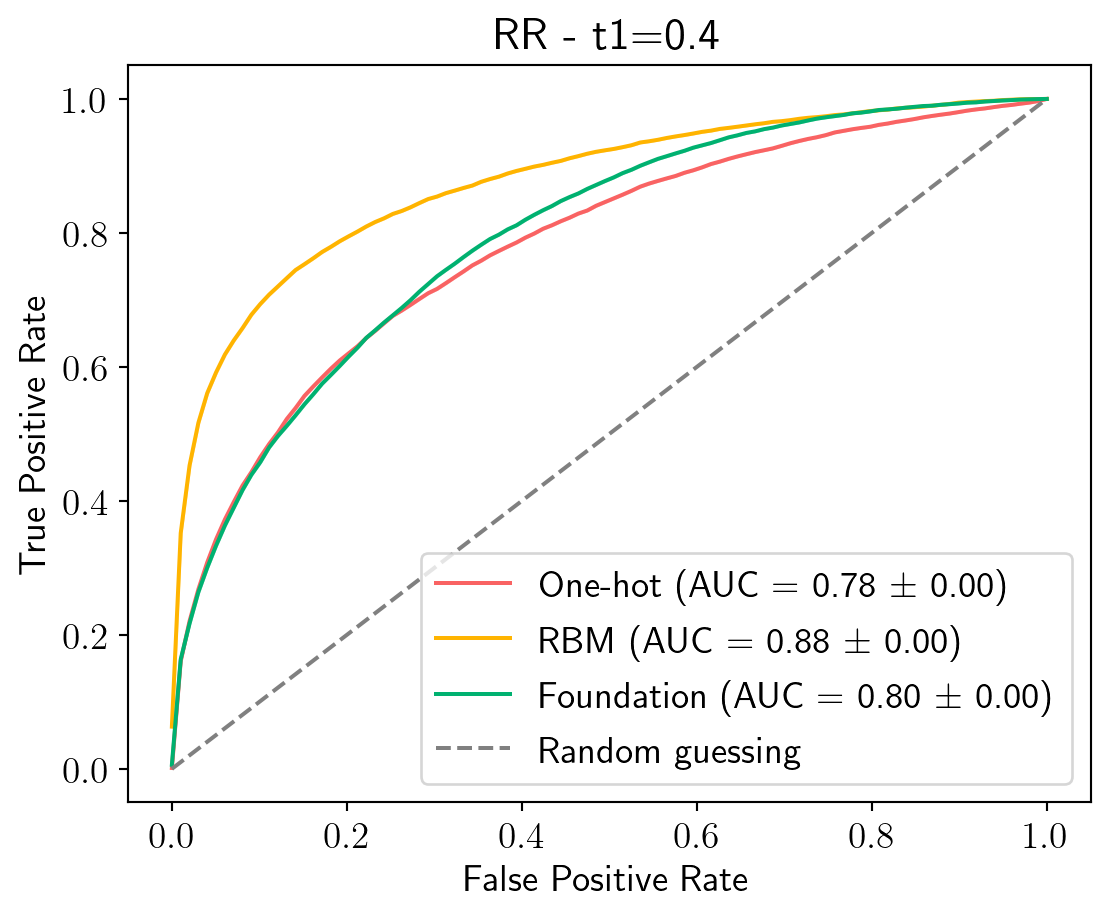

In [50]:
predictor = "logreg"
seeds = [2]

fig, ax = plt.subplots(figsize=(6, 5), dpi=192)
colors = {
    "One-hot": "#f96363",
    "RBM": "#ffb400",
    "Foundation": "#00b170",
}
for method in methods:
    results = roc_curve_stats(method, num_train_samples=100, seeds=seeds, predictor=predictor)
    mean_fpr = results["mean_fpr"]
    mean_tpr = results["mean_tpr"]
    mean_auc = results["mean_auc"]
    std_tpr = results["std_tpr"]
    std_auc = results["std_auc"]
    ax.plot(mean_fpr, mean_tpr, color=colors[method], label=r"{method} (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})".format(method=method, mean_auc=mean_auc, std_auc=std_auc))
    ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[method], alpha=0.2)
        
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
#ax.set_title(f't1={t1}')
ax.set_title(f"{dataset} - t1={t1}")
ax.legend()
plt.tight_layout()

## Analysis on Response Regulators

In [51]:
dataset = "RR"
t1 = 0.4
seed = 2
methods = ["One-hot", "RBM", "Foundation"]
method_to_id = {
    "One-hot": "onehot",
    "RBM": "rbm",
    "Foundation": "plm"
}
path_repo = f"../outputs/{dataset}/t1_{t1}/seed_{seed}/predictions"

In [52]:
data = load_data("One-hot", 5000, 1)
# print the internal structure of the data object
def print_structure(obj, indent=0):
    for key in obj.keys():
        print(" " * indent + str(key))
        if isinstance(obj[key], h5py.Group):
            print_structure(obj[key], indent + 4)
print_structure(data)

info
test
    headers
    labels_true
    predictions
        SVM
            labels_pred
            labels_probs
        logreg
            labels_pred
            labels_probs
        random_forest
            labels_pred
            labels_probs
train
    headers
    labels_true


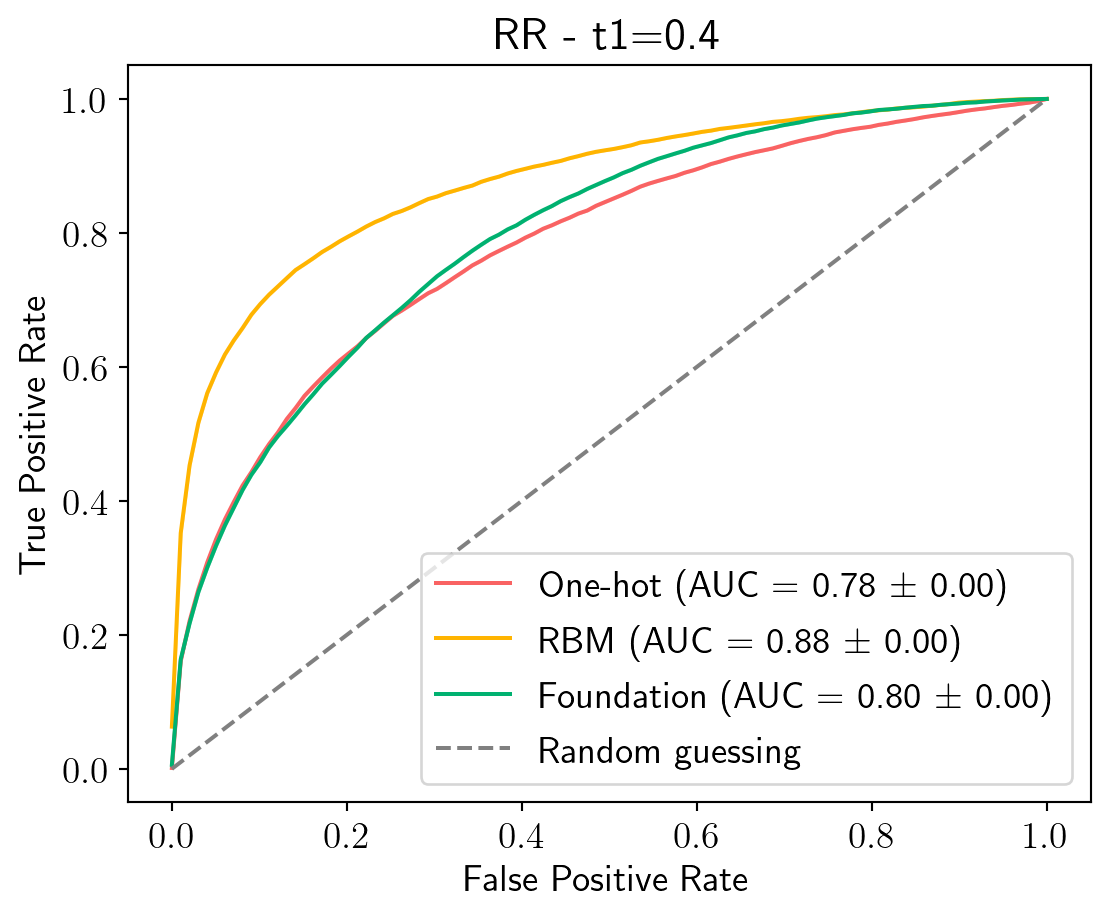

In [53]:
predictor = "logreg"
seeds = [2]

fig, ax = plt.subplots(figsize=(6, 5), dpi=192)
colors = {
    "One-hot": "#f96363",
    "RBM": "#ffb400",
    "Foundation": "#00b170",
}
for method in methods:
    results = roc_curve_stats(method, num_train_samples=100, seeds=seeds, predictor=predictor)
    mean_fpr = results["mean_fpr"]
    mean_tpr = results["mean_tpr"]
    mean_auc = results["mean_auc"]
    std_tpr = results["std_tpr"]
    std_auc = results["std_auc"]
    ax.plot(mean_fpr, mean_tpr, color=colors[method], label=r"{method} (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})".format(method=method, mean_auc=mean_auc, std_auc=std_auc))
    ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[method], alpha=0.2)
        
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
#ax.set_title(f't1={t1}')
ax.set_title(f'{dataset} - t1={t1}')
ax.legend()
plt.tight_layout()

Roc curves by label

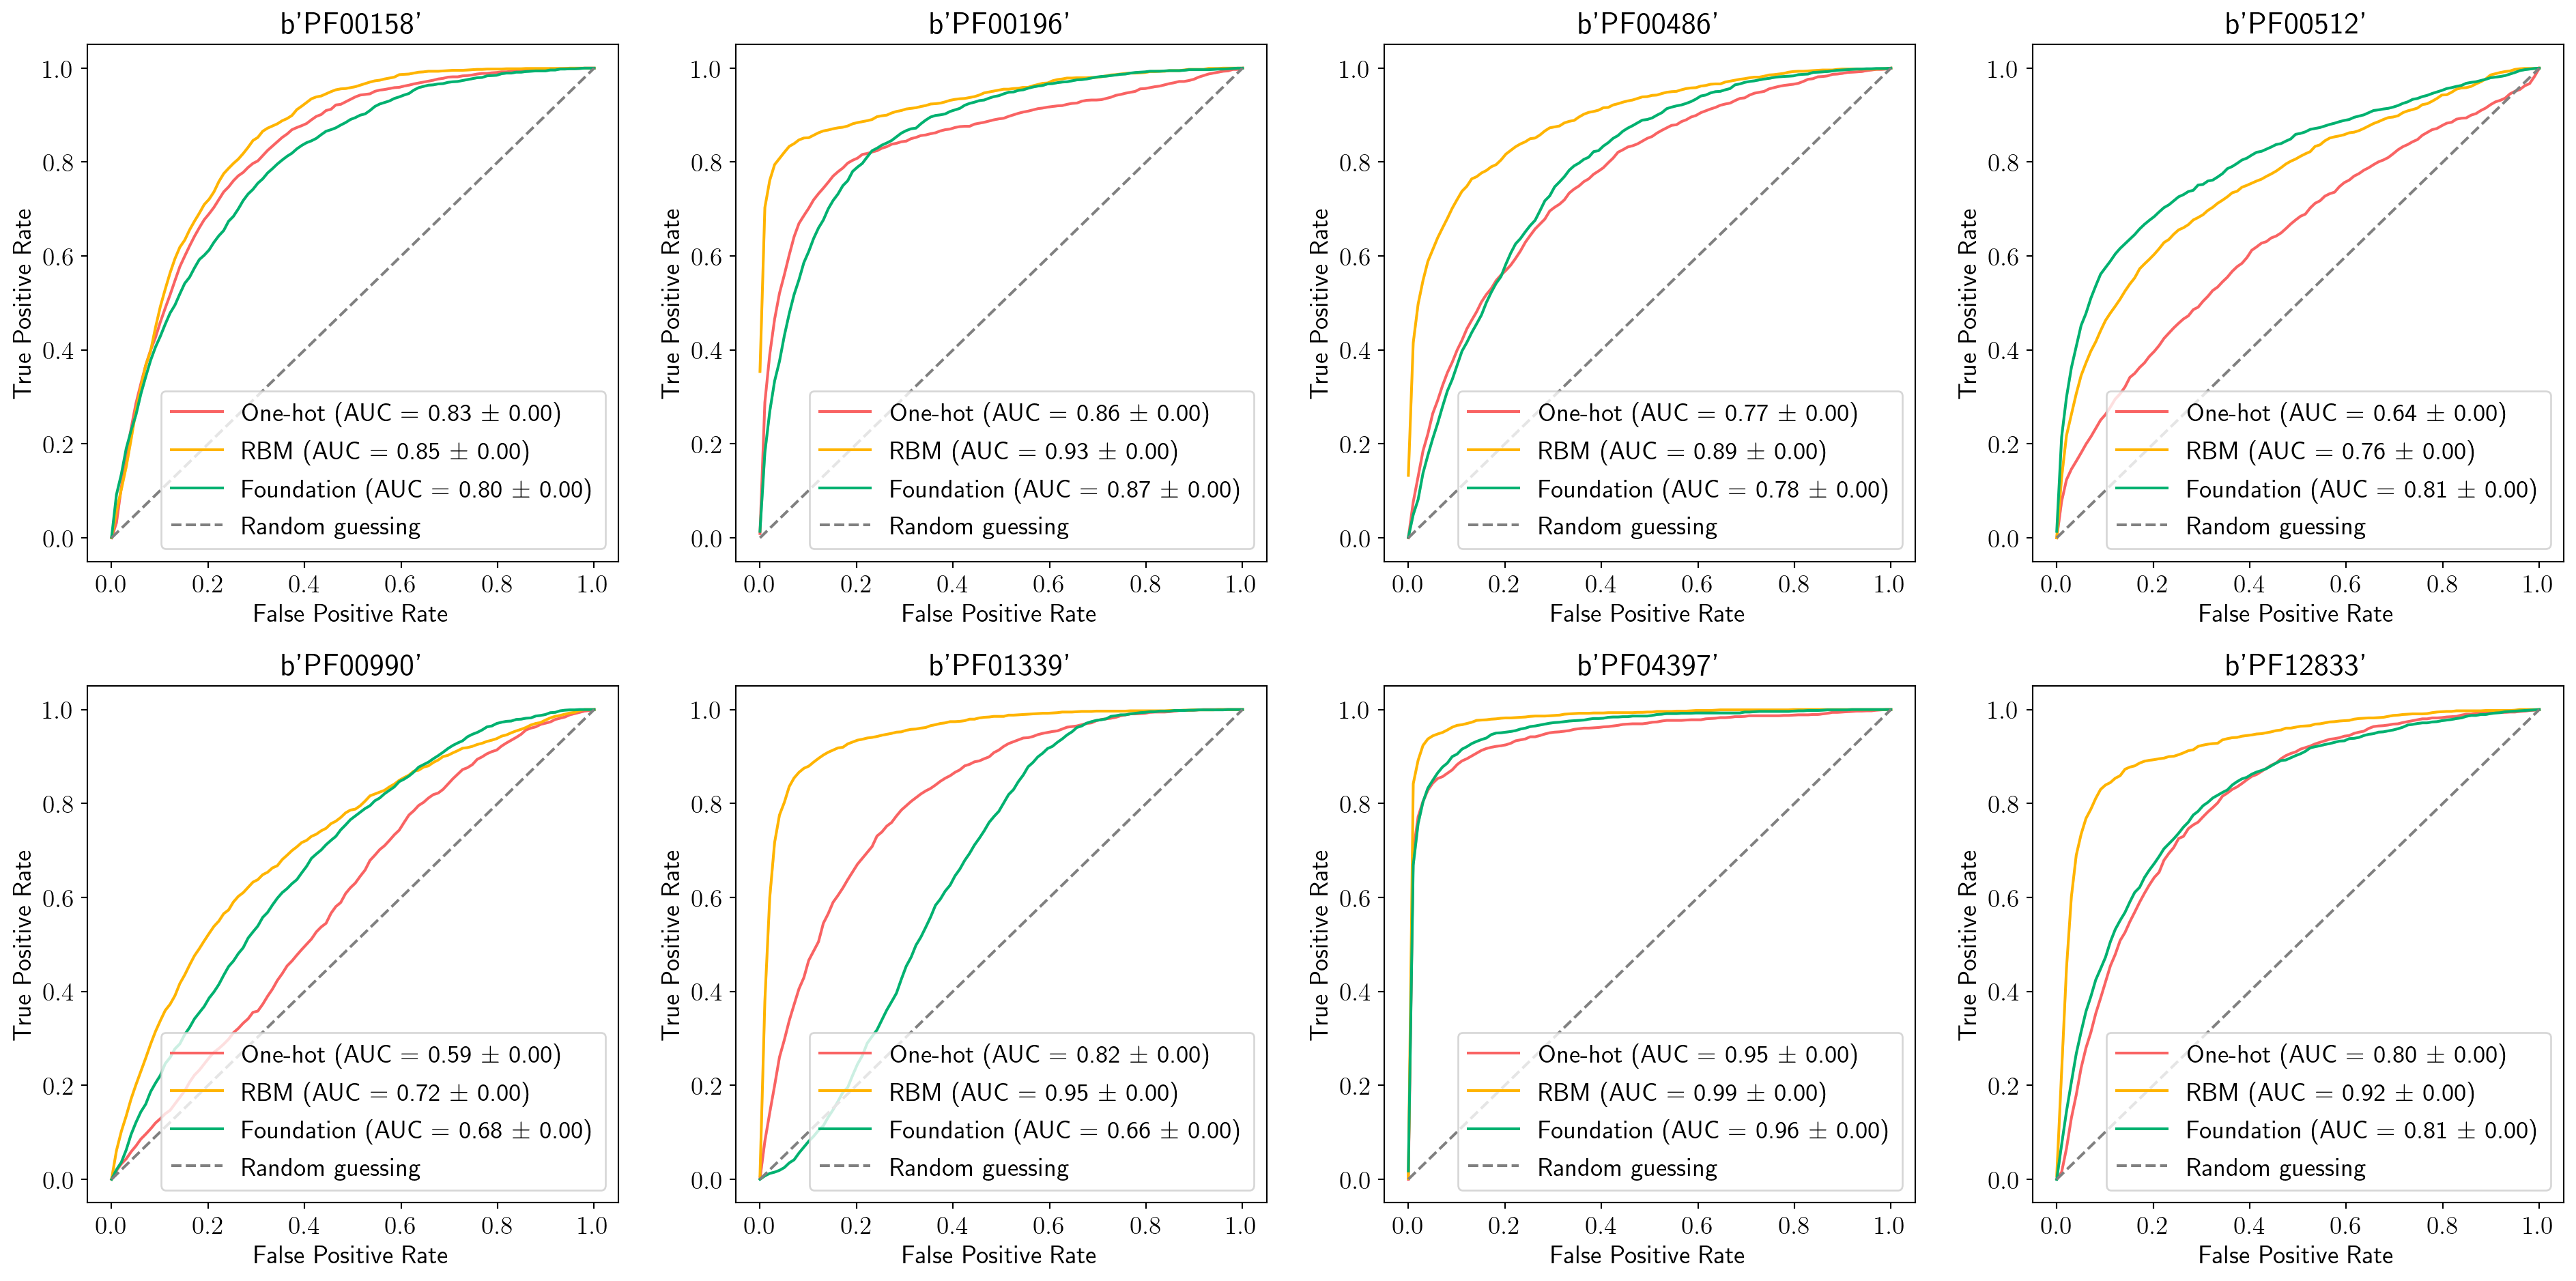

In [54]:
unique_labels = np.unique(data["test"]["labels_true"][()])
# Plot the ROC curves by label using roc_data
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), dpi=192)
axes = axes.flatten()
for i, label in enumerate(unique_labels):
    ax = axes[i]
    for method in methods:
        results = roc_curve_stats_single_label(label, method, num_train_samples=100, seeds=seeds, predictor=predictor)
        mean_fpr = results["mean_fpr"]
        mean_tpr = results["mean_tpr"]
        mean_auc = results["mean_auc"]
        std_tpr = results["std_tpr"]
        std_auc = results["std_auc"]
        ax.plot(mean_fpr, mean_tpr, color=colors[method], label=r"{method} (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})".format(method=method, mean_auc=mean_auc, std_auc=std_auc))
        ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[method], alpha=0.2)
    
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{label}')
    ax.legend()
    
# for ax in axes[-1:]:
#     ax.axis('off')  # Hide unused subplots   
    
plt.tight_layout()
plt.show()

F1 scores for different methods and number of training sequences

In [55]:
# create a dataframe gathering f1 scores for all methods, seeds and number of training samples
predictor = "logreg"
f1_scores = []
for method in methods:
    for num_train_samples in [100, 500, 1000, 2000, 5000]:
        for seed in seeds:
            data = load_data(method, num_train_samples, seed)
            y_true = data["test"]["labels_true"].asstr()[()]
            y_pred = data["test"]["predictions"][predictor]["labels_pred"][()].astype(str)
            f1 = f1_score(y_true, y_pred, average="micro")
            f1_scores.append({
                "method": method,
                "num_train_samples": num_train_samples,
                "seed": seed,
                "f1_score": f1
            })
df_f1 = pd.DataFrame(f1_scores)

In [56]:
# for num_train_samples in [100, 500, 1000, 2000] and each method, produce a dataframe with a columns: method, num_train_samples, f1 score
num_train_samples_list = [100, 500, 1000, 2000, 5000]
def get_df_f1_scores(data, y_true, seed):
    f1_scores = []
    for method in methods:
        for num_train_samples in num_train_samples_list:
            data = load_data(method, num_train_samples, seed)
            y_labels = data["test"]["predictions"][predictor]["labels_pred"][()].astype(str)
            f1 = f1_score(y_true, y_labels, average='macro')
            f1_scores.append({
                "method": method,
                "num_train_samples": num_train_samples,
                "f1_score": f1
            })
    return pd.DataFrame(f1_scores)

df_f1_scores = get_df_f1_scores(data, y_true, seed)


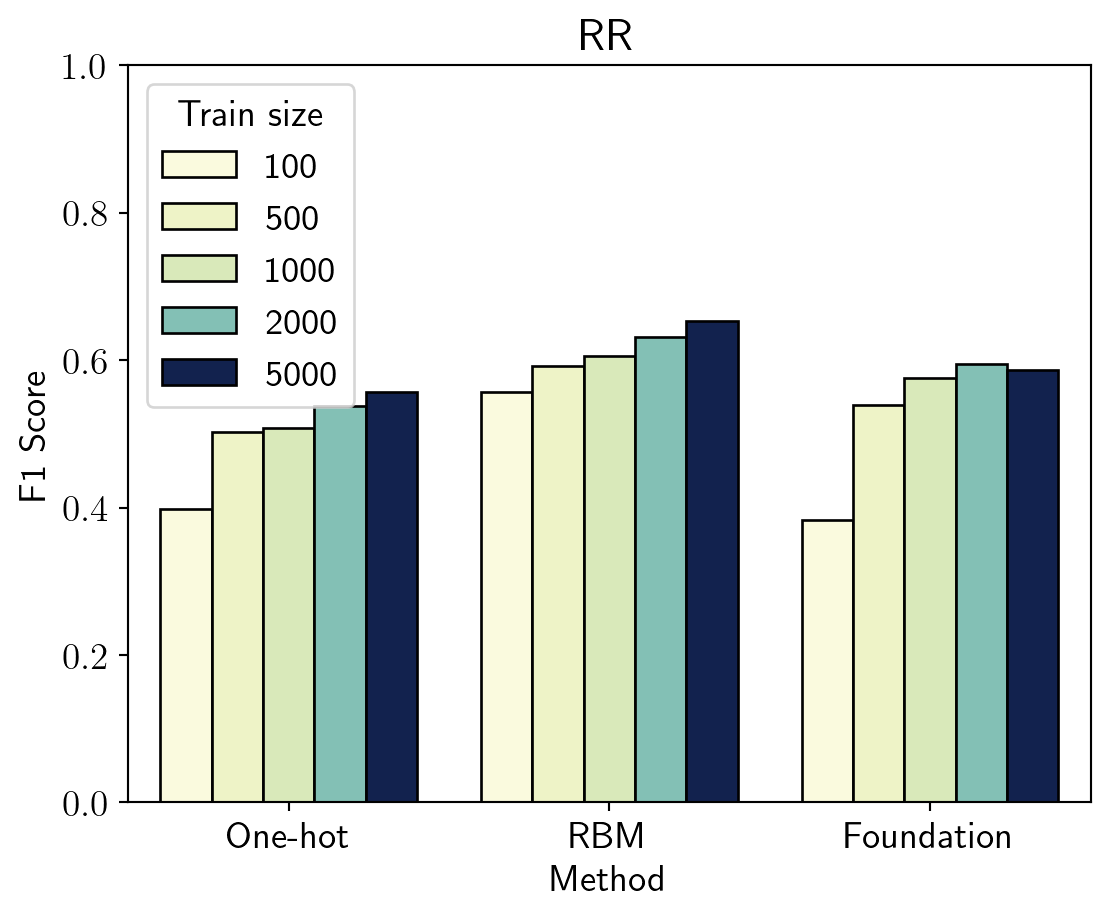

In [57]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=192)
sns.barplot(
    data=df_f1_scores,
    x="method",
    y="f1_score",
    hue="num_train_samples",
    ax=ax,
    palette="YlGnBu",
    edgecolor="black",   # Add black border to bars
    linewidth=1          # Set border thickness
)
ax.set_ylabel(r"F1 Score")
ax.legend(title="Train size", loc='upper left')
ax.set_ylim(0, 1)
#ax.set_title(f"t1={t1}")
ax.set_title(f"{dataset}")
ax.set_xlabel("Method")
plt.tight_layout()
plt.show()

# Average across different seeds

In [165]:
# Produce a ROC curve averaged across different seeds with also the standard deviation as a shaded area
seeds = np.arange(1, 11, 1)  # Seeds from 1 to 10

colors = {
    "msa": "#f96363",
    "rbm": "#ffb400",
    "foundation": "#00b170",
    "contrastive": "#9a80ff",
}
fpr_all = {method: [] for method in methods}
tpr_all = {method: [] for method in methods}
roc_auc_all = {method: [] for method in methods}
for seed in seeds:
    fname_test = f"../experiments/datasets/{dataset}/t1{t1}_t20.7_repeated/seed_{seed}.test.csv"
    df_test = pd.read_csv(fname_test)
    y_true = df_test["label"].values
    unique_labels = np.unique(y_true)
    data = {method: load_data(method, num_train_samples, seed) for method in methods}
    for i, method in enumerate(methods):
        y_scores = data[method]["probs"]
        if len(unique_labels) == 2:
            fpr, tpr, roc_auc = compute_roc_curve(y_true, y_scores[:, 1])
        else:
            fpr, tpr, roc_auc, roc_data_method = multiclass_average_roc(y_true, y_scores)
        fpr_all[method].append(fpr)
        tpr_all[method].append(tpr)
        roc_auc_all[method].append(roc_auc)

In [166]:
# interpolate tpr at common fpr points to take average and std
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = {method: [] for method in methods}
std_tpr = {method: [] for method in methods}
mean_auc = {method: 0 for method in methods}
std_auc = {method: 0 for method in methods}
for method in methods:
    tprs = []
    aucs = roc_auc_all[method]
    for i in range(len(fpr_all[method])):
        interp_tpr = np.interp(mean_fpr, fpr_all[method][i], tpr_all[method][i])
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
    mean_tpr[method] = np.mean(tprs, axis=0)
    std_tpr[method] = np.std(tprs, axis=0)
    mean_auc[method] = np.mean(aucs)
    std_auc[method] = np.std(aucs)

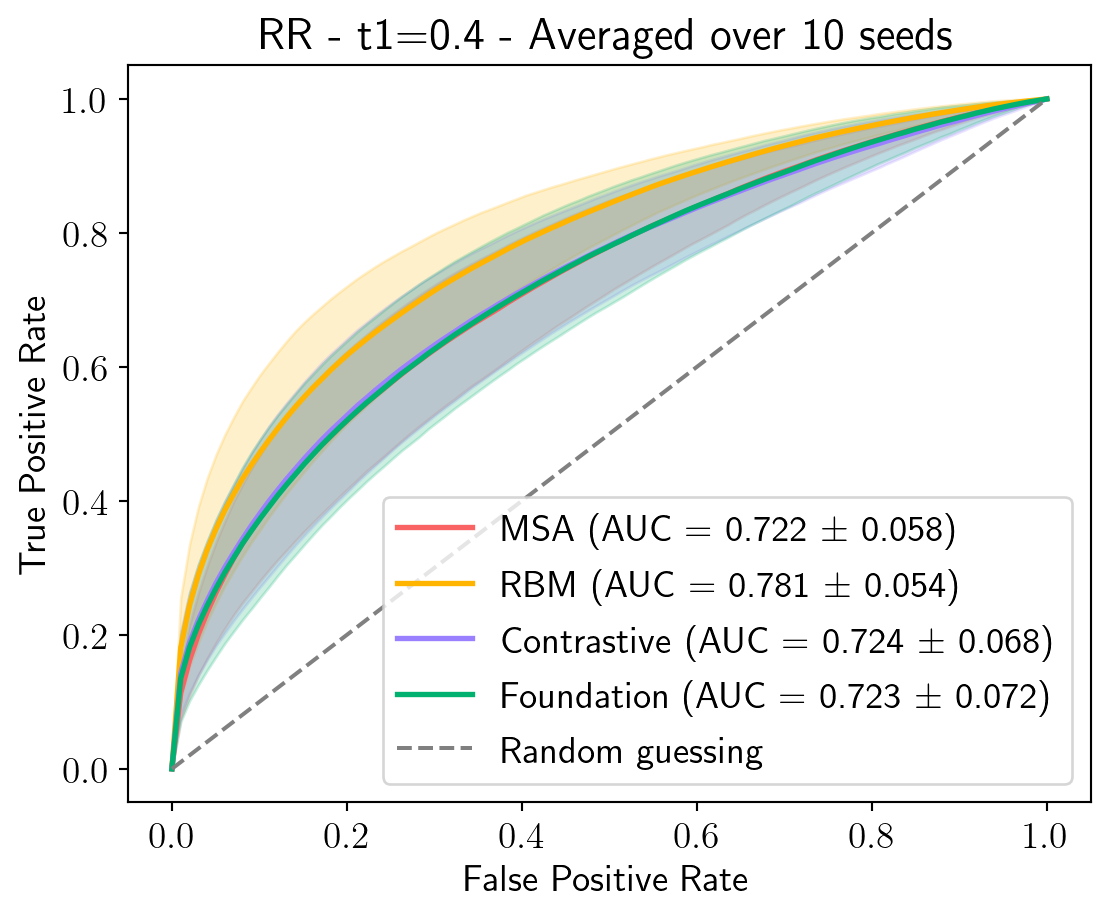

In [167]:
# plot with shaded area
fig, ax = plt.subplots(figsize=(6, 5), dpi=192)
for method in methods:
    color = colors[method.lower()]
    ax.plot(mean_fpr, mean_tpr[method], color=color,
            label=fr"{method} (AUC = {mean_auc[method]:.3f} $\pm$ {std_auc[method]:.3f})",
            linewidth=2)
    tpr_upper = np.minimum(mean_tpr[method] + std_tpr[method], 1)
    tpr_lower = np.maximum(mean_tpr[method] - std_tpr[method], 0)
    ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color=color, alpha=0.2)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
#ax.set_title(f't1={t1} - Averaged over seeds')
ax.set_title(f'RR - t1={t1} - Averaged over {len(seeds)} seeds')
ax.legend()
plt.tight_layout()
plt.show()

In [168]:
# average t1 scores across different seeds
df_f1_scores_all = pd.DataFrame()
for seed in seeds:
    fname_test = f"../experiments/datasets/{dataset}/t1{t1}_t20.7_repeated/seed_{seed}.test.csv"
    df_test = pd.read_csv(fname_test)
    y_true = df_test["label"].values
    unique_labels = np.unique(y_true)
    data = {method: load_data(method, num_train_samples, seed) for method in methods}
    df_f1_scores_seed = get_df_f1_scores(data, y_true, seed)
    df_f1_scores_all = pd.concat([df_f1_scores_all, df_f1_scores_seed], ignore_index=True)

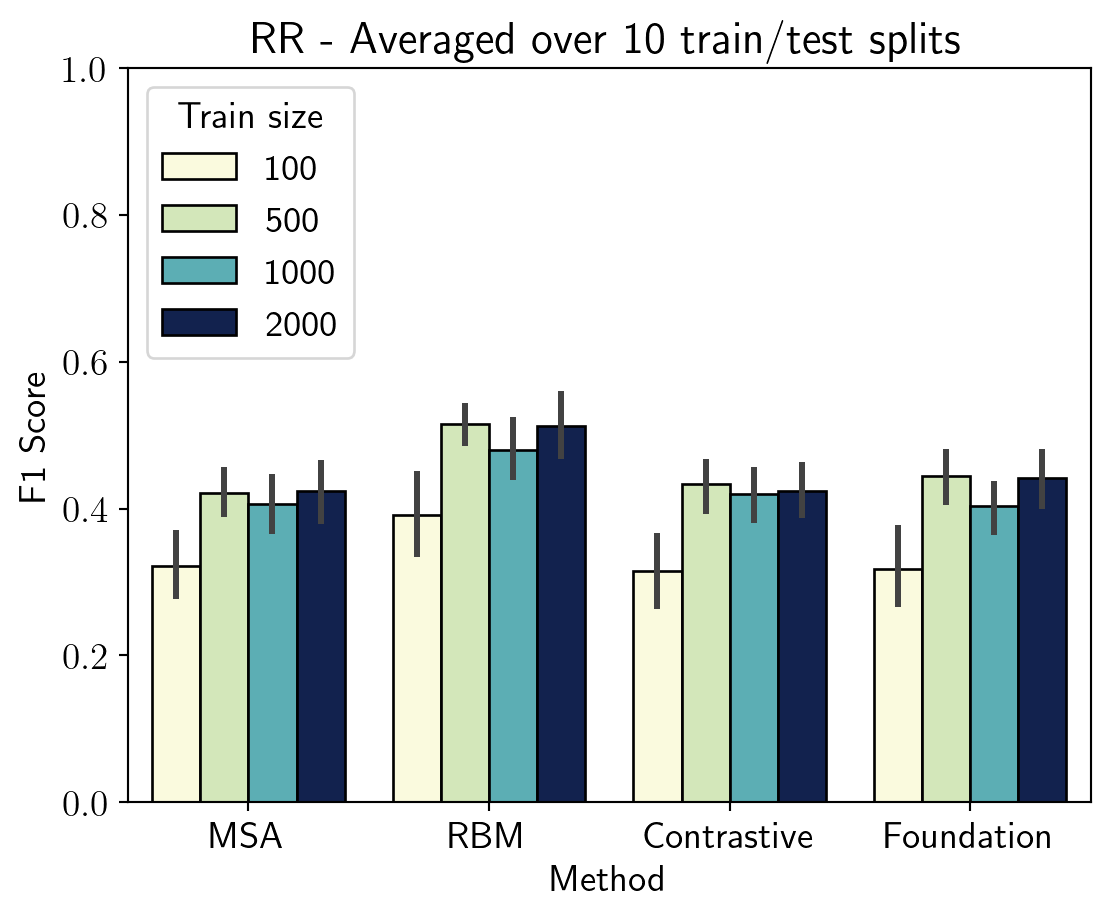

In [169]:
# display bar plot of average f1 scores with error bars
fig, ax = plt.subplots(figsize=(6, 5), dpi=192)
sns.barplot(
    data=df_f1_scores_all,
    x="method",
    y="f1_score",
    hue="num_train_samples",
    ax=ax,
    palette="YlGnBu",
    edgecolor="black",   # Add black border to bars
    linewidth=1          # Set border thickness
)
ax.set_ylabel(r"F1 Score")
ax.legend(title="Train size", loc='upper left')
ax.set_ylim(0, 1)
#ax.set_title(f"t1={t1} - Averaged over seeds")
ax.set_title(f"{dataset} - Averaged over {len(seeds)} train/test splits")
ax.set_xlabel("Method")
plt.tight_layout()
plt.show()